# Notebook para analizar el tiempo de ejecución de vectores topológicos

In [12]:
from pathlib import Path
import re
import pandas as pd

archivo = Path("/files2/gerardo/KmerTopology/data/processed/selected_genomes/time/tiempos.txt")

texto = archivo.read_text()

longitudes = [
    int(x) for x in re.findall(r"Longitud de la secuencia (\d+)", texto)
]

tiempos = [
    float(x) for x in re.findall(r"([\d.]+) s por secuencia", texto)
]

df = pd.DataFrame({
    "longitud": longitudes,
    "tiempo_s": tiempos
})

df

,longitud,tiempo_s
0,79812,3006.5
1,94547,5751.5
2,25857,109.5
3,41706,386.3
4,40053,341.4
5,38609,312.8
6,31048,171.9
7,57839,1037.5
8,52753,754.5
9,94867,5843.3


In [13]:
print(f"Número de secuencias: {len(df)}")
print(f"Longitudes encontradas: {len(longitudes)}")
print(f"Tiempos encontrados: {len(tiempos)}")

df.describe()

Número de secuencias: 29
Longitudes encontradas: 29
Tiempos encontrados: 29


,longitud,tiempo_s
count,29.000000,29.000000
mean,51813.241379,1376.606897
std,22528.020120,1810.380646
min,10853.000000,18.100000
25%,40053.000000,341.400000
50%,45976.000000,494.000000
75%,60525.000000,1449.000000
max,94867.000000,5843.300000


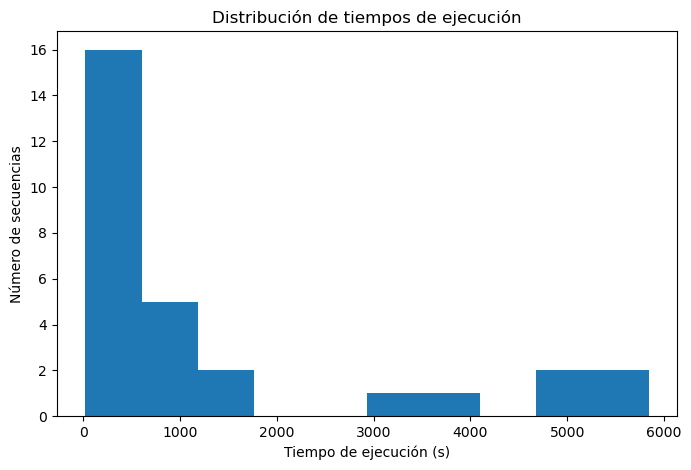

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 5))

plt.hist(df["tiempo_s"], bins=10)

plt.xlabel("Tiempo de ejecución (s)")
plt.ylabel("Número de secuencias")
plt.title("Distribución de tiempos de ejecución")

plt.show()

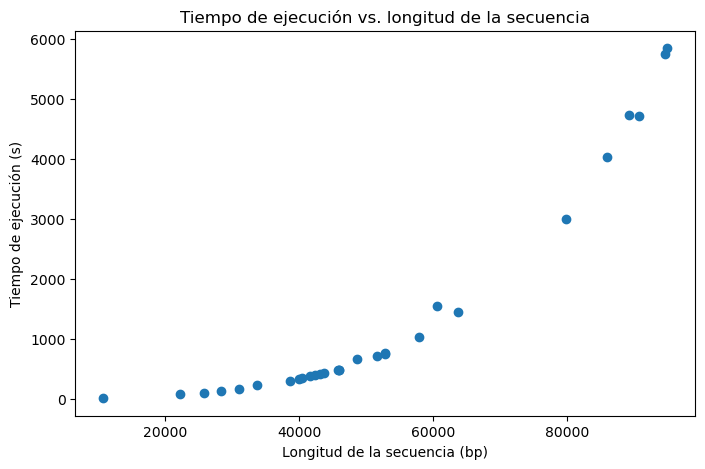

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(df["longitud"], df["tiempo_s"])

plt.xlabel("Longitud de la secuencia (bp)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución vs. longitud de la secuencia")

plt.show()

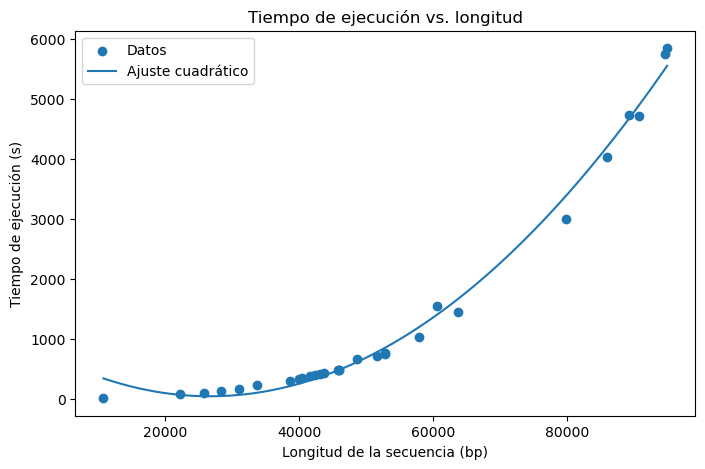

In [16]:
import numpy as np

x = df["longitud"].values
y = df["tiempo_s"].values

coef = np.polyfit(x, y, 2)
polinomio = np.poly1d(coef)

x_ajuste = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Datos")
plt.plot(x_ajuste, polinomio(x_ajuste), label="Ajuste cuadrático")

plt.xlabel("Longitud de la secuencia (bp)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución vs. longitud")

plt.legend()
plt.show()

In [25]:
archivo = Path("/files2/gerardo/KmerTopology/data/processed/selected_genomes/time/tiempos_82.txt")
archivo2 = Path("/files2/gerardo/KmerTopology/data/processed/optimized_pipeline/time/tiempos_82.txt")

texto = archivo.read_text()
texto2 = archivo2.read_text()

longitudes = [
    int(x) for x in re.findall(r"Longitud de la secuencia (\d+)", texto)
]

tiempos = [
    float(x) for x in re.findall(r"([\d.]+) s por secuencia", texto)
]

print("Longitudes:", len(longitudes))
print("Tiempos:", len(tiempos))

df = pd.DataFrame({
    "longitud": longitudes,
    "tiempo_s": tiempos
})

df

longitudes2 = [
    int(x) for x in re.findall(r"Longitud de la secuencia (\d+)", texto2)
]

tiempos2 = [
    float(x) for x in re.findall(r"([\d.]+) s por secuencia", texto2)
]

print("Longitudes:", len(longitudes2))
print("Tiempos:", len(tiempos2))

df2 = pd.DataFrame({
    "longitud": longitudes2,
    "tiempo_s": tiempos2
})

df2

Longitudes: 81
Tiempos: 81
Longitudes: 82
Tiempos: 82


,longitud,tiempo_s
0,67551,45.6
1,42327,28.7
2,14727,10.8
3,65820,42.9
4,22326,15.6
...,...,...
77,65428,43.5
78,26295,18.0
79,28961,20.4
80,94547,61.9


In [27]:
print(f"Número de secuencias: {len(df)}")
print(f"Longitudes encontradas: {len(longitudes)}")
print(f"Tiempos encontrados: {len(tiempos)}")

df.describe()

Número de secuencias: 81
Longitudes encontradas: 81
Tiempos encontrados: 81


,longitud,tiempo_s
count,81.000000,81.000000
mean,66984.222222,5662.933333
std,46849.071070,10102.268502
min,2277.000000,1.500000
25%,28961.000000,154.900000
50%,56482.000000,1021.300000
75%,95850.000000,5990.100000
max,187909.000000,47407.500000


In [26]:
print(f"Número de secuencias: {len(df2)}")
print(f"Longitudes encontradas: {len(longitudes2)}")
print(f"Tiempos encontrados: {len(tiempos2)}")

df2.describe()

Número de secuencias: 82
Longitudes encontradas: 82
Tiempos encontrados: 82


,longitud,tiempo_s
count,82.000000,82.000000
mean,66906.634146,45.028049
std,46564.282005,31.265467
min,2277.000000,2.600000
25%,29184.250000,20.400000
50%,58113.500000,38.650000
75%,95524.250000,62.875000
max,187909.000000,128.100000


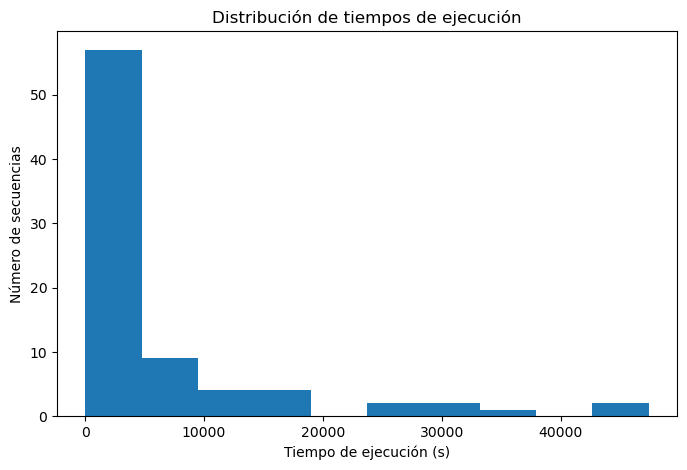

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 5))

plt.hist(df["tiempo_s"], bins=10)

plt.xlabel("Tiempo de ejecución (s)")
plt.ylabel("Número de secuencias")
plt.title("Distribución de tiempos de ejecución")

plt.show()

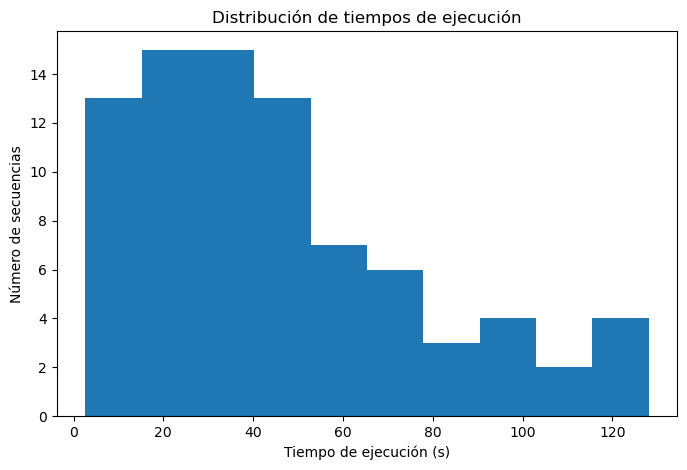

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(df2["tiempo_s"], bins=10)

plt.xlabel("Tiempo de ejecución (s)")
plt.ylabel("Número de secuencias")
plt.title("Distribución de tiempos de ejecución")

plt.show()

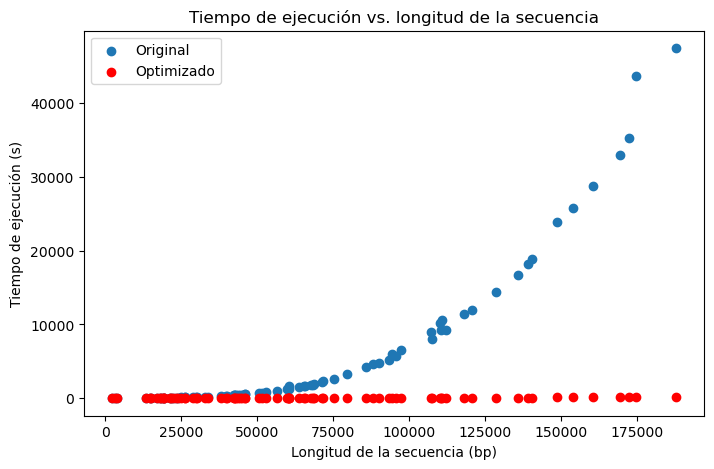

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(df["longitud"], df["tiempo_s"], label="Original")
plt.scatter(df2["longitud"], df2["tiempo_s"], color="red", label="Optimizado")

plt.xlabel("Longitud de la secuencia (bp)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución vs. longitud de la secuencia")
plt.legend()
plt.show()

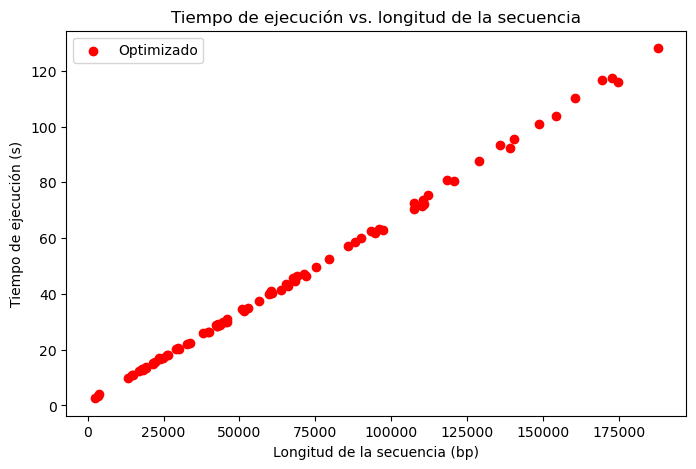

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(df2["longitud"], df2["tiempo_s"], color="red", label="Optimizado")
plt.xlabel("Longitud de la secuencia (bp)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución vs. longitud de la secuencia")
plt.legend()
plt.show()

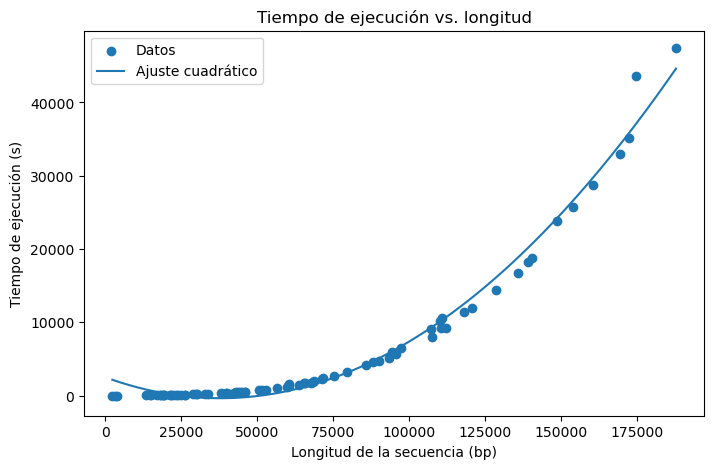

In [23]:
x = df["longitud"].values
y = df["tiempo_s"].values

coef = np.polyfit(x, y, 2)
polinomio = np.poly1d(coef)

x_ajuste = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Datos")
plt.plot(x_ajuste, polinomio(x_ajuste), label="Ajuste cuadrático")

plt.xlabel("Longitud de la secuencia (bp)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Tiempo de ejecución vs. longitud")

plt.legend()
plt.show()